# GOOGL Next-Day Return Forecasting and Backtest

**Goal:** Download historical stock data, compute returns, fit a model to predict returns, evaluate it, and compute:
- Annualized Return
- Sharpe Ratio
- Sortino Ratio

In [1]:
%pip install -q yfinance pandas numpy matplotlib scikit-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error



## Configuration

In [3]:
TICKER = "GOOGL"         
YEARS_BACK = 5
END_DATE = "2026-10-01"   # fixed end date so results are reproducible           
RESAMPLE_FREQ = "D"      
TRAIN_RATIO = 0.8        

RISK_FREE_ANNUAL = 0.00

TRADING_DAYS = 252       

## Download prices and compute returns

In [4]:
end = pd.Timestamp(END_DATE)
start = end - pd.DateOffset(years=YEARS_BACK)

raw = yf.download(TICKER, start=start, end=end, progress=False)

print("Downloaded rows:", len(raw))
display(raw.head())

Downloaded rows: 1254


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2021-10-01,135.255951,135.619995,132.809232,133.180198,35360000
2021-10-04,132.399612,134.678918,129.814713,134.678918,51202000
2021-10-05,134.740845,135.931027,132.777532,132.777532,32404000
2021-10-06,136.268326,136.451580,133.281746,133.479857,24364000
2021-10-07,137.912643,138.721944,137.344049,137.582775,25110000


In [5]:
if "Close" not in raw.columns:
    raise ValueError("No 'Close' column found. Try a different ticker or data source.")

df = raw[["Close"]].copy()
df = df.rename(columns={"Close": "close"})

if RESAMPLE_FREQ == "D":
    resampled = df.copy()
elif RESAMPLE_FREQ == "M":
    resampled = df.resample("M").last()
else:
    resampled = df.resample(RESAMPLE_FREQ).last()

resampled["close"] = resampled["close"].ffill()
resampled = resampled.dropna()

display(resampled.head())
print("Resampled rows:", len(resampled))

Price,close
Ticker,GOOGL
Date,
2021-10-01,135.255951
2021-10-04,132.399612
2021-10-05,134.740845
2021-10-06,136.268326
2021-10-07,137.912643


Resampled rows: 1254


In [6]:
data = resampled.copy()

# Simple returns: r_t = (P_t / P_{t-1}) - 1
data["ret"] = data["close"].pct_change()

# Log returns: ln(P_t / P_{t-1})
data["log_ret"] = np.log(data["close"] / data["close"].shift(1))

data = data.dropna()
display(data.head())

Price,close,ret,log_ret
Ticker,GOOGL,,
Date,,,
2021-10-04,132.399612,-0.021118,-0.021344
2021-10-05,134.740845,0.017683,0.017529
2021-10-06,136.268326,0.011336,0.011273
2021-10-07,137.912643,0.012067,0.011995
2021-10-08,138.467896,0.004026,0.004018


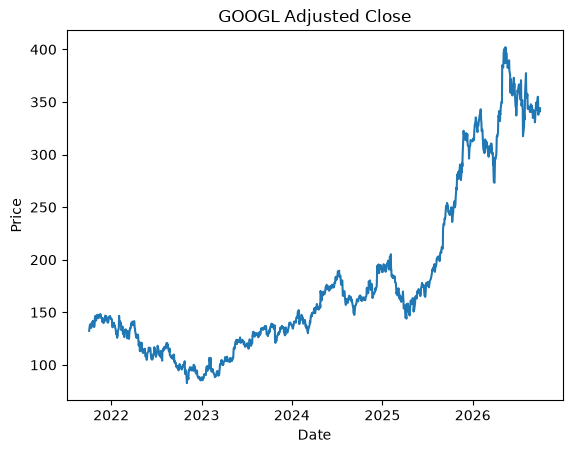

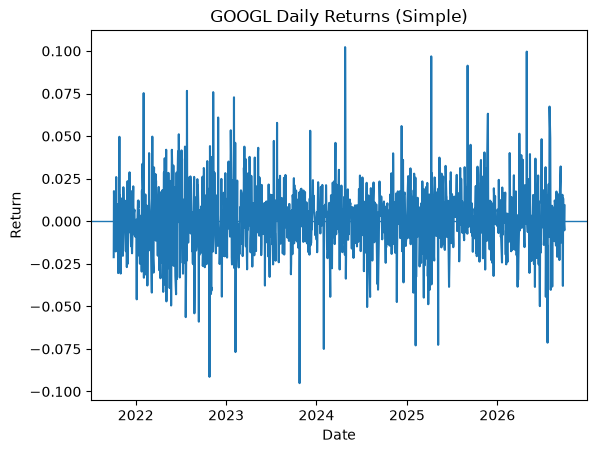

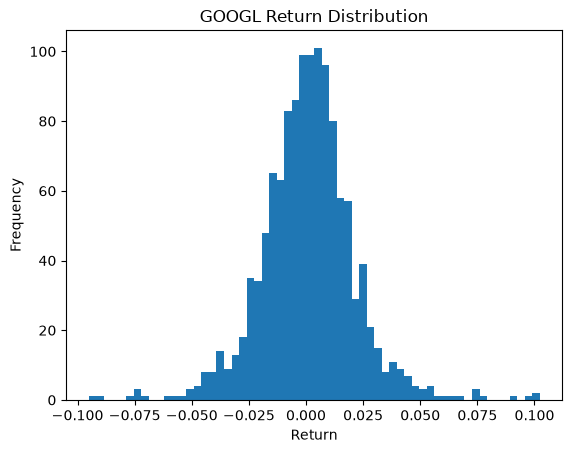

In [7]:
plt.figure()
plt.plot(data.index, data["close"])
plt.title(f"{TICKER} Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

plt.figure()
plt.plot(data.index, data["ret"])
plt.title(f"{TICKER} Daily Returns (Simple)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.axhline(0, linewidth=1)
plt.show()

plt.figure()
plt.hist(data["ret"], bins=60)
plt.title(f"{TICKER} Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

## Features and target

In [8]:
feat = data.copy()

# Lags of returns
for lag in range(1, 6):
    feat[f"ret_lag_{lag}"] = feat["ret"].shift(lag)

# Rolling stats (volatility proxies)
feat["ret_roll_mean_5"] = feat["ret"].rolling(5).mean()
feat["ret_roll_std_5"]  = feat["ret"].rolling(5).std()
feat["ret_roll_mean_20"] = feat["ret"].rolling(20).mean()
feat["ret_roll_std_20"]  = feat["ret"].rolling(20).std()

# Target = next period return (unseen future)
feat["target_next_ret"] = feat["ret"].shift(-1)

feat = feat.dropna()

X = feat.drop(columns=["target_next_ret", "close", "ret", "log_ret"])
y = feat["target_next_ret"]

print("Feature matrix shape:", X.shape)
display(X.head())

Feature matrix shape: (1233, 9)


Price,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5,ret_roll_mean_5,ret_roll_std_5,ret_roll_mean_20,ret_roll_std_20
Ticker,,,,,,,,,
Date,,,,,,,,,
2021-10-29,-0.002520,0.049595,0.013543,-0.000869,-0.030444,0.014963,0.020962,0.004197,0.017493
2021-11-01,0.015064,-0.002520,0.049595,0.013543,-0.000869,0.008991,0.029225,0.003716,0.018337
2021-11-02,-0.030727,0.015064,-0.002520,0.049595,0.013543,0.008980,0.029223,0.003506,0.018192
2021-11-03,0.013488,-0.030727,0.015064,-0.002520,0.049595,0.000664,0.018851,0.003340,0.018132
2021-11-04,0.008014,0.013488,-0.030727,0.015064,-0.002520,0.003445,0.019284,0.003306,0.018115


## Chronological train/test split

In [9]:
split_idx = int(len(feat) * TRAIN_RATIO)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

test_index = y_test.index

print("Train range:", X_train.index.min(), "->", X_train.index.max(), "rows:", len(X_train))
print("Test range: ", X_test.index.min(),  "->", X_test.index.max(),  "rows:", len(X_test))

Train range: 2021-10-29 00:00:00 -> 2025-10-03 00:00:00 rows: 986
Test range:  2025-10-06 00:00:00 -> 2026-09-29 00:00:00 rows: 247


## Model vs. baseline

In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

baseline_pred = np.full_like(y_test.values, fill_value=y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = rmse(y_test, baseline_pred)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
model_rmse = rmse(y_test, pred)

results = pd.DataFrame({
    "actual_next_ret": y_test.values,
    "pred_next_ret": pred
}, index=test_index)

print("Baseline MAE:", baseline_mae, "Baseline RMSE:", baseline_rmse)
print("Model    MAE:", mae, "Model    RMSE:", model_rmse)

# Direction matters more than magnitude for a long/flat strategy
hit_rate = (np.sign(pred) == np.sign(y_test.values)).mean()
up_rate = (y_test.values > 0).mean()   # baseline: always predict "up"
print(f"Directional accuracy: {hit_rate:.3f}  (always-up baseline: {up_rate:.3f})")

display(results.head())

Baseline MAE: 0.014708067407744137 Baseline RMSE: 0.02006007871230754
Model    MAE: 0.014917492685416181 Model    RMSE: 0.02028150896890765
Directional accuracy: 0.462  (always-up baseline: 0.502)


,actual_next_ret,pred_next_ret
Date,,
2025-10-06,-0.018648,0.000956
2025-10-07,-0.004639,0.001147
2025-10-08,-0.012632,0.000438
2025-10-09,-0.020536,0.002094
2025-10-10,0.032041,0.002218


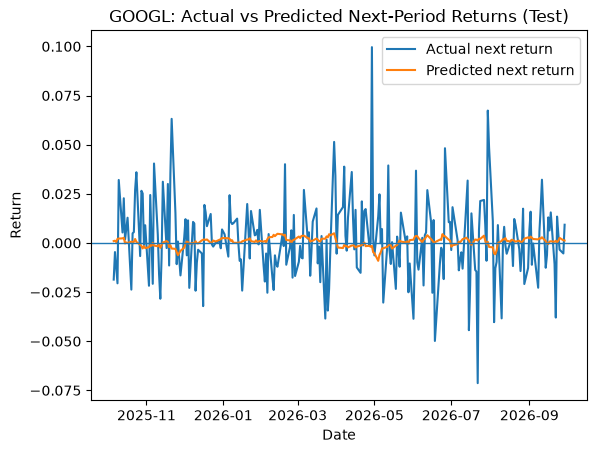

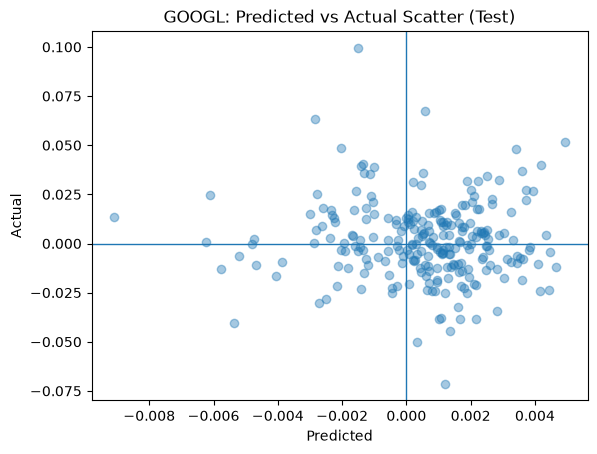

In [11]:
plt.figure()
plt.plot(results.index, results["actual_next_ret"], label="Actual next return")
plt.plot(results.index, results["pred_next_ret"], label="Predicted next return")
plt.title(f"{TICKER}: Actual vs Predicted Next-Period Returns (Test)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.axhline(0, linewidth=1)
plt.legend()
plt.show()

plt.figure()
plt.scatter(results["pred_next_ret"], results["actual_next_ret"], alpha=0.4)
plt.title(f"{TICKER}: Predicted vs Actual Scatter (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.show()

## Risk metrics

In [12]:
def annualized_return(returns: pd.Series, periods_per_year: int = TRADING_DAYS) -> float:
    """
    Geometric annualized return based on periodic returns.
    """
    returns = returns.dropna()
    if len(returns) == 0:
        return np.nan
    total_growth = (1 + returns).prod()
    n_periods = len(returns)
    return total_growth ** (periods_per_year / n_periods) - 1


def sharpe_ratio(returns: pd.Series, risk_free_annual: float = RISK_FREE_ANNUAL, periods_per_year: int = TRADING_DAYS) -> float:
    """
    Annualized Sharpe ratio using periodic returns.
    """
    returns = returns.dropna()
    if len(returns) < 2:
        return np.nan

    rf_periodic = (1 + risk_free_annual) ** (1 / periods_per_year) - 1
    excess = returns - rf_periodic

    if excess.std(ddof=1) == 0:
        return np.nan

    return (excess.mean() / excess.std(ddof=1)) * np.sqrt(periods_per_year)


def sortino_ratio(returns: pd.Series, risk_free_annual: float = RISK_FREE_ANNUAL, periods_per_year: int = TRADING_DAYS) -> float:
    """
    Annualized Sortino ratio using downside deviation.
    """
    returns = returns.dropna()
    if len(returns) < 2:
        return np.nan

    rf_periodic = (1 + risk_free_annual) ** (1 / periods_per_year) - 1
    excess = returns - rf_periodic

    downside = excess[excess < 0]
    downside_dev = downside.std(ddof=1)

    if downside_dev == 0 or np.isnan(downside_dev):
        return np.nan

    return (excess.mean() / downside_dev) * np.sqrt(periods_per_year)

## Backtest: long/flat strategy vs. buy and hold

,Metric,Prediction Strategy,Buy & Hold
0,Annualized Return,-0.051021,0.386490
1,Sharpe Ratio,-0.082532,1.183006
2,Sortino Ratio,-0.104300,2.002582
3,Days invested,0.692308,1.000000


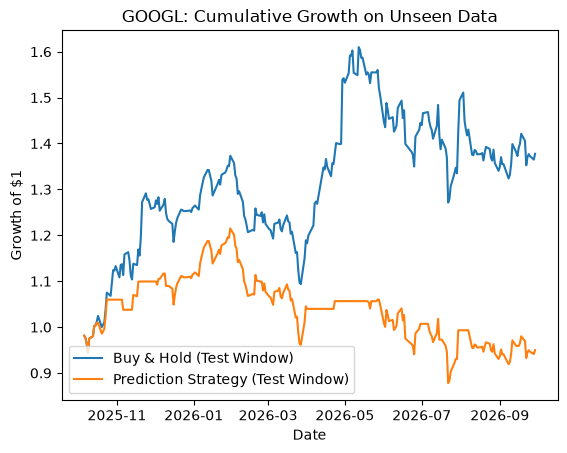

In [13]:
# The signal at day t is a prediction of the return from t to t+1, so it must be
# applied to that NEXT-day return (not the same-day return, which would be look-ahead).
test_returns = results["actual_next_ret"]                 # buy & hold over the test window
signal = (results["pred_next_ret"] > 0).astype(int)      # 1 = invest, 0 = cash
strategy_returns = test_returns * signal

ann_ret_s = annualized_return(strategy_returns, TRADING_DAYS if RESAMPLE_FREQ == "D" else 12)
sharpe_s = sharpe_ratio(strategy_returns, RISK_FREE_ANNUAL, TRADING_DAYS if RESAMPLE_FREQ == "D" else 12)
sortino_s = sortino_ratio(strategy_returns, RISK_FREE_ANNUAL, TRADING_DAYS if RESAMPLE_FREQ == "D" else 12)

ppy = TRADING_DAYS if RESAMPLE_FREQ == "D" else 12
metrics_strategy = pd.DataFrame({
    "Metric": ["Annualized Return", "Sharpe Ratio", "Sortino Ratio", "Days invested"],
    "Prediction Strategy": [ann_ret_s, sharpe_s, sortino_s, signal.mean()],
    "Buy & Hold": [annualized_return(test_returns, ppy), sharpe_ratio(test_returns, RISK_FREE_ANNUAL, ppy),
                   sortino_ratio(test_returns, RISK_FREE_ANNUAL, ppy), 1.0],
})

display(metrics_strategy)

# Plot cumulative growth comparison (stock vs strategy)
stock_curve = (1 + test_returns).cumprod()
strategy_curve = (1 + strategy_returns).cumprod()

plt.figure()
plt.plot(stock_curve.index, stock_curve.values, label="Buy & Hold (Test Window)")
plt.plot(strategy_curve.index, strategy_curve.values, label="Prediction Strategy (Test Window)")
plt.title(f"{TICKER}: Cumulative Growth on Unseen Data")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()